In [14]:
# Local modules
import os
import pickle
from typing import Dict, Union

# 3rd party modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pylab import mpl
from scipy.signal import savgol_filter
from typing import Dict, List
from scipy.fftpack import fft
import math
import json


def getTrajectoryEnergy(vellist):
    steptime = len(vellist)
    Fs = 10
    vellist_fq = fft(vellist)
    vellist_fq_half = vellist_fq[0:int(steptime / 2 + 1)]
    A = np.abs(vellist_fq_half)
    f = np.arange(int(steptime / 2 + 1)) * Fs / steptime
    A_adj = np.zeros(int(steptime / 2 + 1))
    A_adj[0] = A[0] / steptime
    A_adj[len(A_adj) - 1] = A[len(A) - 1] / steptime
    A_adj[1:len(A_adj) - 2] = 2 * A[1:len(A) - 2] / steptime
    Energy = 0
    for i in np.arange(len(f) - 1):
        Energy = Energy + A_adj[i] * f[i] * f[i] * (f[i + 1] - f[i])
    return Energy


def getEnergylist(vellist):
    steptime = len(vellist)
    Fs = 10
    vellist_fq = fft(vellist)
    vellist_fq_half = vellist_fq[0:int(steptime / 2 + 1)]
    A = np.abs(vellist_fq_half)
    f = np.arange(int(steptime / 2 + 1)) * Fs / steptime
    A_adj = np.zeros(int(steptime / 2 + 1))
    A_adj[0] = A[0] / steptime
    A_adj[len(A_adj) - 1] = A[len(A) - 1] / steptime
    A_adj[1:len(A_adj) - 2] = 2 * A[1:len(A) - 2] / steptime
    EnergyList = []
    for i in np.arange(len(f) - 1):
        EnergyList.append(A_adj[i])
    return EnergyList


class Controller:
    """控制器类，封装PID/IDM/CACC/LCM四种算法，与车辆绑定"""

    def __init__(self, car):
        """初始化控制器，绑定到具体车辆"""
        self.car = car  # 关联的车辆对象
        self.reset()  # 初始化控制器状态

    def reset(self):
        """重置控制器状态（如PID积分项）"""
        if self.car.m_mode == "PID":
            self.car.m_integral = 0
            self.car.m_preverror = 0
        # 其他控制器若有状态变量，在此添加重置逻辑

    def compute_acceleration(self, forecar_vel, forecar_acc=None):
        """根据车辆模式选择对应算法计算加速度"""
        mode = self.car.m_mode
        if mode == "PID":
            return self._pid(forecar_vel)
        elif mode == "IDM":
            return self._idm(forecar_vel)
        elif mode == "CACC":
            return self._cacc(forecar_vel, forecar_acc)
        elif mode == "LCM":
            return self._lcm(forecar_vel)
        return 0  # 无控制器时返回0

    # ------------------------------
    # 各控制器核心算法
    # ------------------------------
    def _pid(self, forecar_vel):
        """PID控制器算法"""
        error = forecar_vel - self.car.m_speed
        dt = 0.1  # 时间步长

        # 积分项累加
        self.car.m_integral += error * dt
        # 微分项计算
        derivative = (error - self.car.m_preverror) / dt if dt != 0 else 0

        # 计算加速度（使用车辆自身的PID参数）
        acc = (self.car.m_kp * error
               + self.car.m_ki * self.car.m_integral
               + self.car.m_kd * derivative)

        # 更新前向误差
        self.car.m_preverror = error
        return acc

    def _idm(self, forecar_vel):
        """IDM控制器算法"""
        current_speed = self.car.m_speed
        minimum_gap = 2  # 最小安全距离
        vf = 50  # 期望速度

        # 计算安全距离s_star
        v_term = current_speed * self.car.m_T
        s_star = minimum_gap + max(0, v_term)  # 避免负项

        # 计算IDM加速度（使用车辆自身的IDM参数）
        acc = self.car.m_a * (
                1 - (current_speed / vf) ** self.car.m_delta
                - (s_star / self.car.m_dis) ** 2
        )
        return acc

    def _cacc(self, forecar_vel, forecar_acc):
        """CACC控制器算法"""
        current_speed = self.car.m_speed

        # 计算期望距离（使用车辆自身的CACC参数）
        expect_dis = self.car.m_veh_Tc * current_speed + self.car.m_veh_s0
        e = self.car.m_dis - expect_dis  # 距离误差
        error = forecar_vel - current_speed  # 速度误差

        # 计算加速度（包含前车加速度前馈）
        acc = (self.car.m_j1 * e
               + self.car.m_j2 * error
               + self.car.m_j3 * (forecar_acc or 0))
        return acc

    def _lcm(self, forecar_vel):
        """LCM控制器算法"""
        current_speed = self.car.m_speed
        vf = 200  # 期望速度

        # 计算期望距离（使用车辆自身的LCM参数）
        expect_dis = self.car.m_h_T * current_speed + self.car.m_s0

        # 计算LCM加速度
        acc = self.car.m_A * (
                1 - current_speed / vf
                - math.exp(1 - self.car.m_dis / expect_dis)
        )
        return acc


class Car:
    def __init__(self, id, speed=0, dis=0, mode="", modenum="", Length=3):
        # 基础属性（简化命名，明确含义）
        self.m_id = id  # 车辆ID
        self.m_Length = Length  # 车辆长度
        self.m_speed = speed  # 当前速度
        self.m_dis = dis  # 与前车的距离
        self.m_mode = mode  # 控制器模式（如"PID"）
        self.m_modenum = modenum  # 控制器参数字符串

        # 轨迹数据（统一管理历史记录）
        self.m_vellist = [speed]  # 速度历史列表
        self.m_dislist = [dis]  # 距离历史列表
        self.m_vellist_list = []  # 多轮测试速度轨迹集合
        self.m_dislist_list = []  # 多轮测试距离轨迹集合

        # 评估指标（单独分组，便于维护）
        self.m_test_veldiffsumlist = []  # 速度误差总和列表
        self.m_test_dissumlist = []  # 距离误差总和列表
        self.m_is_collosion = []  # 碰撞记录
        self.m_score = []  # 评分记录
        self.m_energy = []  # 能量消耗
        self.m_energylist = []  # 能量消耗历史

        # 控制器参数（按类型分组，减少属性冗余）
        self._init_controller_params()

        # 解析参数并初始化控制器（核心：每个车辆绑定自己的控制器）
        self.parse_parameters()
        self.controller = Controller(self) if mode else None  # 头车无控制器

    def _init_controller_params(self):
        """初始化所有控制器的默认参数（集中管理）"""
        # PID参数
        self.m_kp = 0.3
        self.m_ki = 0.05
        self.m_kd = 0.1
        self.m_integral = 0  # PID积分项（状态变量）
        self.m_preverror = 0  # PID前向误差（状态变量）

        # IDM参数
        self.m_a = 2.0
        self.m_b = 1.0
        self.m_delta = 2.0
        self.m_T = 1.2

        # LCM参数
        self.m_A = 4.0
        self.m_h_T = 1.2
        self.m_s0 = 2.0

        # CACC参数
        self.m_j1 = 0.25
        self.m_j2 = 1.76
        self.m_j3 = 0.26
        self.m_veh_s0 = 2.0
        self.m_veh_Tc = 1.2

    def parse_parameters(self):
        """解析参数字符串，更新控制器参数（优化解析逻辑）"""
        if not self.m_modenum:
            return  # 头车或无参数时直接返回

        # 分割参数（兼容格式："kp=0.3,ki=0.25"）
        try:
            params = {}
            for pair in self.m_modenum.split(","):
                key, value = pair.split("=")
                params[key.strip()] = float(value.strip())
        except Exception as e:
            print(f"参数解析错误: {e}")
            return

        # 根据模式更新对应参数（避免硬编码索引，提高容错性）
        if self.m_mode == "PID":
            self.m_kp = params.get("kp", self.m_kp)
            self.m_ki = params.get("ki", self.m_ki)
            self.m_kd = params.get("kd", self.m_kd)
        elif self.m_mode == "IDM":
            self.m_a = params.get("a", self.m_a)
            self.m_b = params.get("b", self.m_b)
            self.m_delta = params.get("delta", self.m_delta)
            self.m_T = params.get("T", self.m_T)
        elif self.m_mode == "CACC":
            self.m_j1 = params.get("j1", self.m_j1)
            self.m_j2 = params.get("j2", self.m_j2)
            self.m_j3 = params.get("j3", self.m_j3)
            self.m_veh_s0 = params.get("veh_s0", self.m_veh_s0)
            self.m_veh_Tc = params.get("veh_Tc", self.m_veh_Tc)
        elif self.m_mode == "LCM":
            self.m_A = params.get("A", self.m_A)
            self.m_h_T = params.get("h_T", self.m_h_T)
            self.m_s0 = params.get("s0", self.m_s0)

    def reset(self):
        """重置车辆状态（用于多轮测试，调用控制器重置方法）"""
        # 重置速度和距离历史
        self.m_vellist.clear()
        self.m_dislist.clear()
        # 重置控制器状态（如PID积分项）
        if self.controller:
            self.controller.reset()


class CarController:
    def __init__(self, car):
        """初始化控制器，绑定到特定车辆"""
        self.car = car
        self.reset_state()  # 重置控制器状态

    def reset_state(self):
        """重置控制器内部状态（如PID的积分项）"""
        self.car.m_integral = 0
        self.car.m_preverror = 0

    def compute_acceleration(self, forecar_vel, distance, forecar_acc=None):
        """根据车辆模式选择对应的控制算法"""
        mode = self.car.m_mode

        if mode == "PID":
            return self._compute_pid(forecar_vel, distance)
        elif mode == "IDM":
            return self._compute_idm(forecar_vel, distance)
        elif mode == "CACC":
            return self._compute_cacc(forecar_vel, distance, forecar_acc)
        elif mode == "LCM":
            return self._compute_lcm(forecar_vel, distance)
        else:
            return 0  # 默认返回0加速度（无控制器）

    def _compute_pid(self, forecar_vel, distance):
        """PID控制器算法"""
        current_speed = self.car.m_speed
        error = forecar_vel - current_speed

        # 计算PID各项
        self.car.m_integral += error * 0.1  # 积分项
        derivative = (error - self.car.m_preverror) / 0.1  # 微分项

        # 计算加速度
        acc = (self.car.m_kp * error +
               self.car.m_ki * self.car.m_integral +
               self.car.m_kd * derivative)

        # 更新历史误差
        self.car.m_preverror = error
        return acc

    def _compute_idm(self, forecar_vel, distance):
        """IDM控制器算法"""
        current_speed = self.car.m_speed
        vf = 50  # 期望速度

        # 计算期望安全距离
        v_term = current_speed * self.car.m_T
        s_star = 2 + max(0, v_term)  # 最小安全距离+速度相关项

        # 计算IDM加速度
        acc = self.car.m_a * (1 -
                              (current_speed / vf) ** self.car.m_delta -
                              (s_star / distance) ** 2)
        return acc

    def _compute_cacc(self, forecar_vel, distance, forecar_acc):
        """CACC控制器算法"""
        current_speed = self.car.m_speed

        # 计算期望距离
        expect_dis = self.car.m_veh_Tc * current_speed + self.car.m_veh_s0

        # 计算各项误差
        e = distance - expect_dis  # 距离误差
        error = forecar_vel - current_speed  # 速度误差

        # 计算CACC加速度（包含前馈项）
        acc = (self.car.m_j1 * e +
               self.car.m_j2 * error +
               self.car.m_j3 * (forecar_acc or 0))
        return acc

    def _compute_lcm(self, forecar_vel, distance):
        """LCM控制器算法"""
        current_speed = self.car.m_speed
        vf = 200  # 期望速度

        # 计算期望距离
        expect_dis = self.car.m_h_T * current_speed + self.car.m_s0

        # 计算LCM加速度
        acc = self.car.m_A * (1 -
                              current_speed / vf -
                              math.exp(1 - distance / expect_dis))
        return acc


class Trajectory:
    def __init__(self, vellist):
        self.m_vellist = vellist.flatten() if hasattr(vellist, 'flatten') else vellist
        self.m_maxvel = max(self.m_vellist)
        self.m_minvel = min(self.m_vellist)
        self.m_meanvel = sum(self.m_vellist) / len(self.m_vellist)
        self.m_Distance = sum(self.m_vellist)
        self.m_length = len(self.m_vellist)
        self.m_score = 0
        # 处理空列表情况，避免索引错误
        self.acclist = [self.m_vellist[i + 1] - self.m_vellist[i] for i in range(len(self.m_vellist) - 1)]
        self.maxacc = max(self.acclist)
        self.minacc = min(self.acclist)

        self.m_velErrorLCM = 0
        self.m_velErrorCACC = 0
        self.m_velErrorIDM = 0
        self.m_velErrorPID = 0


        self.m_disErrorLCM = 0
        self.m_disErrorCACC = 0
        self.m_disErrorIDM = 0
        self.m_disErrorPID = 0

        self.m_energyLCM = 0
        self.m_energyCACC = 0
        self.m_energyIDM = 0
        self.m_energyPID = 0

        self.m_scoreLCM = 0
        self.m_scoreCACC = 0
        self.m_scoreIDM = 0
        self.m_scorePID = 0

        self.m_is_collosion_PID = 0
        self.m_is_collosion_LCM = 0
        self.m_is_collosion_CACC = 0
        self.m_is_collosion_IDM = 0


def reinitcar(carlist):
    """初始化车辆（调用Car类的reset方法，简化逻辑）"""
    for car in carlist:
        if car.m_id == 0:
            continue  # 头车不重置

        # 初始速度和距离（跟随头车）
        init_vel = carlist[0].m_vellist[0]
        init_dis = init_vel * 1.2 + 2

        # 重置车辆状态
        car.m_speed = init_vel
        car.m_dis = init_dis
        car.m_vellist = [init_vel]
        car.m_dislist = [init_dis]
        car.reset()  # 调用车辆自身的重置方法

        # 重置评估指标
        car.m_score.append(0)
        car.m_is_collosion.append(False)


def getmodenum(mode):
    """获取控制器参数字符串（使用字典优化，便于扩展）"""
    mode_params = {
        "PID": "kp=0.3,ki=0.25,kd=0.1",
        "IDM": "a=4.0,b=4.0,delta=2.0,T=1.2",
        "CACC": "j1=0.25,j2=1.76,j3=0.26,veh_s0=2,veh_Tc=1.2",
        "LCM": "A=4,h_T=1.2,s0=2"
    }
    return mode_params.get(mode, "")


def TestWithgenerated_data(generated_data_test, mode, platoonSize):

    modenum = getmodenum(mode)
    generated_data = [Trajectory(i) for i in generated_data_test]

    # 创建车辆列表（每个车辆自动初始化控制器）
    carlist = [
        Car(
            id=i,
            speed=0,
            dis=0,
            mode="" if i == 0 else mode,
            modenum="" if i == 0 else modenum,
            Length=3
        )
        for i in range(platoonSize)
    ]

    for n in range(len(generated_data)):
        # 设置头车轨迹
        carlist[0].m_vellist = [max(0, v) for v in generated_data[n].m_vellist.copy()]
        reinitcar(carlist)  # 初始化车辆

        # 遍历时间步
        for i in range(len(carlist[0].m_vellist) - 1):
            for car in carlist[1:]:  # 处理跟驰车辆
                forecar = carlist[car.m_id - 1]
                forecar_vel = forecar.m_vellist[i]

                # 计算前车加速度（用于CACC）
                forecar_acc = (forecar.m_vellist[i] - forecar.m_vellist[i - 1])*10 if i > 0 else 0

                # 调用车辆自身的控制器计算加速度
                acc = car.controller.compute_acceleration(
                    forecar_vel=forecar_vel,
                    forecar_acc=forecar_acc
                )
                # 更新车辆状态（速度和距离）
                car.m_speed += acc * 0.1
                car.m_speed = max(0, car.m_speed)  # 速度非负

                speed_error = forecar_vel - car.m_speed
                car.m_dis += speed_error / 10  # 距离更新

                # 碰撞检测
                if car.m_dis <= 0:
                    car.m_dis = 0
                    car.m_speed = forecar_vel
                    car.m_is_collosion[n] = True

                # 记录轨迹
                car.m_vellist.append(car.m_speed)
                car.m_dislist.append(car.m_dis)

        # 保存评估数据
        for car in carlist:
            car.m_dislist_list.append(car.m_dislist.copy())
            car.m_vellist_list.append(car.m_vellist.copy())

            if car.m_id == 0:
                continue  # 头车无需计算误差

            # 计算平均误差
            dissum = 0.0
            veldiffsum = 0.0
            for j in range(len(carlist[0].m_vellist)-1):
                # 期望距离（使用车辆自身的LCM参数，兼容其他模式）
                expect_dis = car.m_h_T * car.m_vellist[j] + car.m_s0
                dissum += abs(car.m_dislist[j] - expect_dis)
                veldiffsum += abs(car.m_vellist[j] - carlist[car.m_id - 1].m_vellist[j])

            # 保存平均误差
            car.m_test_dissumlist.append(dissum / len(carlist[0].m_vellist) * 100)
            car.m_test_veldiffsumlist.append(veldiffsum / len(carlist[0].m_vellist) * 100)
            # 能量计算（假设函数已定义）
            car.m_energy.append(getTrajectoryEnergy(car.m_vellist))
            car.m_energylist.append(getEnergylist(car.m_vellist))


    return carlist


def evaluate_trajectory(oridataset, scaling,platoonSize):
    dataset = oridataset[:, :, 2]

    controllers = ["CACC", "PID", "IDM", "LCM"]
    file_path = "metrics_storage.json"
    with open(file_path, "r") as f:
        metrics = json.load(f)  # 格式：{"CACC": {...}, "PID": {...}, ...}

    # 存储所有控制器的评估结果
    all_results = {}
    all_carlist = {}

    for ctrl in controllers:
        # 1. 生成当前控制器的测试结果
        carlist = TestWithgenerated_data(dataset[:, :] * scaling, ctrl, platoonSize)
        # 提取跟随车（跳过头车，索引0为头车）
        followers = carlist[1:]
        follower_count = len(followers)
        if follower_count == 0:
            print(f"警告：{ctrl} 无跟随车数据，跳过评估")
            continue

        # 2. 遍历每条轨迹，计算评分
        ctrl_trajectories = []
        for traj_idx in range(len(dataset)):
            # 初始化轨迹对象（原始速度轨迹）
            trajectory = Trajectory(dataset[traj_idx] * scaling)

            # 3. 累加所有跟随车的指标
            vel_sum = 0.0  # 速度误差和总和
            dis_sum = 0.0  # 距离误差和总和
            energy_sum = 0.0  # 能量消耗总和
            for car in followers:
                # 累加单条轨迹中所有跟随车的指标
                vel_sum += car.m_test_veldiffsumlist[traj_idx]
                dis_sum += car.m_test_dissumlist[traj_idx]
                energy_sum += car.m_energy[traj_idx]

            # 4. 计算跟随车指标的平均值
            avg_vel = vel_sum / follower_count
            avg_dis = dis_sum / follower_count
            avg_energy = energy_sum / follower_count

            # 5. 归一化函数（统一逻辑：值越小评分越高）
            def normalize(x, metric_info):
                """将指标x归一化到[0,1]，x越小得分越高（因误差/能量越小越好）"""
                max_val = metric_info["max"]
                min_val = metric_info["min"]
                if max_val == min_val:  # 避免除零
                    return 1.0 if x == min_val else 0.0
                if x > max_val:  # 避免除零
                    return 1.0
                if x < min_val:  # 避免除零
                    return 0.0
                        # 核心：反向归一化（x越小，得分越高）
                return ( x-min_val) / (max_val - min_val)

            # 6. 计算各指标得分（权重：距离2分，速度2分，能量1分，总分5分）
            try:
                # 从预存指标中获取当前控制器的参考值
                dis_score = normalize(avg_dis, metrics[ctrl]["m_test_dissumlist"]) * 2
                vel_score = normalize(avg_vel, metrics[ctrl]["m_test_veldiffsumlist"]) * 2
                energy_score = normalize(avg_energy, metrics[ctrl]["m_energy"]) * 1
            except KeyError as e:
                print(f"警告：{ctrl} 缺失指标 {e}，使用默认得分0")
                dis_score = vel_score = energy_score = 0.0

            # 7. 计算总分（归一化到100分制）
            total_score = (dis_score + vel_score + energy_score) / 5 * 100

            # 将得分存入轨迹对象（动态绑定属性，如m_scoreCACC、m_scorePID等）
            setattr(trajectory, f"m_score{ctrl}", total_score)
            setattr(trajectory, f"m_velError{ctrl}", avg_dis)
            setattr(trajectory, f"m_disError{ctrl}", avg_vel)
            setattr(trajectory, f"m_energy{ctrl}", avg_energy)
            print("ctrl:{},total_score:{},avg_dis:{},avg_vel:{},avg_energy:{}".format(ctrl,total_score,avg_dis,avg_vel,avg_energy))


            ctrl_trajectories.append(trajectory)

        # 存储当前控制器的所有轨迹结果
        all_results[ctrl] = ctrl_trajectories
        all_carlist[ctrl] = carlist

    return all_results,all_carlist


def get_evaluate_metrics(dataset, scaling,platoonSize) -> Dict:
    """
    计算并比较不同控制器的评估指标（速度误差、距离误差、能量消耗）
    :param dataset: 输入的轨迹数据集
    :return: 包含所有控制器指标的字典
    """
    # 1. 定义控制器列表及对应的测试函数参数
    controllers = [
        {"name": "CACC", "scaling": scaling},
        {"name": "PID", "scaling": scaling},
        {"name": "IDM", "scaling": scaling},
        {"name": "LCM", "scaling": scaling}
    ]
    metrics_keys = ["m_test_veldiffsumlist", "m_test_dissumlist", "m_energy"]  # 统一指标键

    # 2. 批量运行测试并计算指标
    all_metrics = {}
    for ctrl in controllers:
        ctrl_name = ctrl["name"]
        scaling = ctrl["scaling"]

        try:
            carlist = TestWithgenerated_data(dataset[:, :, 2] * scaling, ctrl_name, platoonSize)

            # 计算该控制器的指标（跳过头车，从索引1开始）
            metrics = _calculate_metrics(carlist[1:], metrics_keys)  # 传入跟驰车辆
            all_metrics[ctrl_name] = metrics

        except Exception as e:
            print(f"计算{ctrl_name}指标时出错: {str(e)}")
            all_metrics[ctrl_name] = {"error": str(e)}  # 记录错误信息

    # 3. 打印结果并保存到文件
    _print_metrics(all_metrics)
    _save_metrics(all_metrics, "metrics_storage.json")

    return all_metrics


def _calculate_metrics(carlist: List, keys: List[str]) -> Dict:
    """
    计算单组控制器的指标（最大值、最小值、平均值），剔除前10%和后10%的极端数据
    :param carlist: 车辆列表（仅包含跟驰车辆，不含头车）
    :param keys: 需要计算的指标键列表
    :return: 包含统计结果的字典
    """
    metrics = {}
    count = len(carlist)

    if count == 0:
        return {"warning": "无有效跟驰车辆数据"}

    for key in keys:
        # 1. 收集所有车辆的指标数据（过滤空列表）
        all_values = []
        for car in carlist:
            attr = getattr(car, key, [])
            if isinstance(attr, list) and len(attr) > 0:
                all_values.extend(attr)

        if not all_values:  # 处理空数据情况
            metrics[key] = {"max": None, "min": None, "avg": None}
            continue

        # 2. 排序并剔除前10%和后10%的极端值
        sorted_values = sorted(all_values)
        total_count = len(sorted_values)

        # 计算剔除的比例（10%），向上取整避免极端情况（如数据量小于10时保留大部分数据）
        trim_count = max(1, int(total_count * 0.05))  # 至少剔除1个，最多剔除10%

        # 剔除后的数据（中间80%）
        trimmed_values = sorted_values[trim_count: total_count - trim_count]

        # 处理剔除后数据为空的极端情况（如原始数据量≤2）
        if not trimmed_values:
            trimmed_values = sorted_values  # 若全部剔除后为空，则保留原始数据
            print(f"警告：{key} 数据量过少（{total_count}条），无法剔除极端值，将使用全部数据")

        # 3. 基于剔除后的数据计算统计值
        metrics[key] = {
            "max": max(trimmed_values),
            "min": min(trimmed_values),
            "avg": sum(trimmed_values) / len(trimmed_values),
            "trimmed_count": len(trimmed_values),  # 新增：剔除后的数据量
            "original_count": total_count  # 新增：原始数据量，便于追溯
        }

    return metrics


def _print_metrics(metrics: Dict) -> None:
    """打印所有控制器的指标结果"""
    for ctrl_name, ctrl_metrics in metrics.items():
        print("\n" + "=" * 50)
        print(f"{ctrl_name} 指标统计：")

        if "error" in ctrl_metrics:
            print(f"  错误: {ctrl_metrics['error']}")
            continue

        for metric, stats in ctrl_metrics.items():
            print(f"  {metric}:")
            print(f"    最大值: {stats['max']:.4f}" if stats['max'] is not None else "    最大值: 无数据")
            print(f"    最小值: {stats['min']:.4f}" if stats['min'] is not None else "    最小值: 无数据")
            print(f"    平均值: {stats['avg']:.4f}" if stats['avg'] is not None else "    平均值: 无数据")

    print("\n" + "=" * 50)


def _save_metrics(metrics: Dict, filename: str) -> None:
    """将指标保存到JSON文件"""
    try:
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(metrics, f, indent=4, ensure_ascii=False)
        print(f"指标已保存到 {filename}")
    except IOError as e:
        print(f"保存文件失败: {str(e)}")


def csv_to_3d_data(csv_path):
    """
    将CSV文件转换为三维数据[车辆数, 时间步, 特征数]
    :param csv_path: CSV文件路径
    :return: 三维数据数组、车辆ID列表
    """
    df = pd.read_csv(csv_path)
    # 获取所有不同的Vehicle_ID
    vehicle_ids = df['Vehicle_ID'].unique()
    # 获取特征列（排除Vehicle_ID）
    feature_cols = [col for col in df.columns if col != 'Vehicle_ID']
    feature_num = len(feature_cols)

    max_time_steps = 0
    # 先遍历找到最大时间步数，方便初始化数组
    for vid in vehicle_ids:
        vehicle_df = df[df['Vehicle_ID'] == vid]
        max_time_steps = max(max_time_steps, len(vehicle_df))

    # 初始化三维数据数组，初始值用NaN填充，之后可根据需求替换
    data_3d = np.full((len(vehicle_ids), max_time_steps, feature_num), np.nan)
    for i, vid in enumerate(vehicle_ids):
        vehicle_df = df[df['Vehicle_ID'] == vid]
        time_steps = len(vehicle_df)
        # 将车辆数据填充到三维数组对应位置
        data_3d[i, :time_steps, :] = vehicle_df[feature_cols].values

    return data_3d, vehicle_ids


def random_select_trajectories(data_3d, vehicle_ids, num_select=1000):
    """
    从三维数据中随机选取指定数量的轨迹（按车辆ID区分）
    :param data_3d: 三维数据数组，形状为[车辆数, 时间步, 特征数]
    :param vehicle_ids: 车辆ID列表
    :param num_select: 要选取的轨迹数量
    :return: 选取的轨迹数据（三维数组子集）、对应的车辆ID列表
    """
    # 获取车辆总数
    total_vehicles = len(vehicle_ids)
    # 随机选择车辆ID的索引
    selected_indices = np.random.choice(total_vehicles, size=num_select, replace=False)
    # 获取对应的车辆ID
    selected_vehicle_ids = vehicle_ids[selected_indices]
    # 获取对应的三维数据子集
    selected_data_3d = data_3d[selected_indices]
    return selected_data_3d, selected_vehicle_ids



In [15]:
gen_data_3d, gen_vehicle_ids = csv_to_3d_data(
    'D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q800_0.8/fake_data_model_epoch_1500.csv'
)
# 转换原始数据
ori_data_3d, ori_vehicle_ids = csv_to_3d_data(
    'D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q800_0.8/train_data.csv'
)

# 从生成数据中随机选1000条轨迹
gen_selected_3d, gen_selected_ids = random_select_trajectories(gen_data_3d, gen_vehicle_ids, num_select=1000)
# 从原始数据中随机选1000条轨迹
ori_selected_3d, ori_selected_ids = random_select_trajectories(ori_data_3d, ori_vehicle_ids, num_select=1000)
print("生成数据三维形状:", gen_selected_3d.shape)
print("原始数据三维形状:", ori_selected_3d.shape)

get_evaluate_metrics(ori_data_3d, 0.3048,2)


生成数据三维形状: (1000, 800, 6)
原始数据三维形状: (1000, 800, 6)

CACC 指标统计：
  m_test_veldiffsumlist:
    最大值: 35.3560
    最小值: 15.7709
    平均值: 24.4123
  m_test_dissumlist:
    最大值: 152.4349
    最小值: 59.3922
    平均值: 98.0240
  m_energy:
    最大值: 0.5036
    最小值: 0.0222
    平均值: 0.1891

PID 指标统计：
  m_test_veldiffsumlist:
    最大值: 113.1267
    最小值: 47.8219
    平均值: 77.6824
  m_test_dissumlist:
    最大值: 657.0757
    最小值: 175.9071
    平均值: 342.2770
  m_energy:
    最大值: 0.5390
    最小值: 0.0230
    平均值: 0.2091

IDM 指标统计：
  m_test_veldiffsumlist:
    最大值: 87.3822
    最小值: 37.0790
    平均值: 60.3450
  m_test_dissumlist:
    最大值: 66.4390
    最小值: 20.7565
    平均值: 42.4562
  m_energy:
    最大值: 0.5058
    最小值: 0.0172
    平均值: 0.1894

LCM 指标统计：
  m_test_veldiffsumlist:
    最大值: 108.1077
    最小值: 44.1961
    平均值: 73.2911
  m_test_dissumlist:
    最大值: 137.2173
    最小值: 42.4129
    平均值: 86.4100
  m_energy:
    最大值: 0.5054
    最小值: 0.0188
    平均值: 0.1915

指标已保存到 metrics_storage.json


{'CACC': {'m_test_veldiffsumlist': {'max': 35.356030151294284,
   'min': 15.77091096352638,
   'avg': 24.412252514795924,
   'trimmed_count': 1279,
   'original_count': 1419},
  'm_test_dissumlist': {'max': 152.43487356336468,
   'min': 59.392171467192576,
   'avg': 98.02398124741318,
   'trimmed_count': 1279,
   'original_count': 1419},
  'm_energy': {'max': 0.5035967922162164,
   'min': 0.022209246577954065,
   'avg': 0.18914109164146145,
   'trimmed_count': 1279,
   'original_count': 1419}},
 'PID': {'m_test_veldiffsumlist': {'max': 113.12665138347384,
   'min': 47.82192739485442,
   'avg': 77.68242023609137,
   'trimmed_count': 1279,
   'original_count': 1419},
  'm_test_dissumlist': {'max': 657.0756721843431,
   'min': 175.9070629607113,
   'avg': 342.2770086950108,
   'trimmed_count': 1279,
   'original_count': 1419},
  'm_energy': {'max': 0.5389847756333804,
   'min': 0.022977851088658435,
   'avg': 0.20906911007706297,
   'trimmed_count': 1279,
   'original_count': 1419}},
 'ID

In [16]:
ori_result_trajectory,ori_result_carlist=evaluate_trajectory(gen_selected_3d, 0.3048,2)

ctrl:CACC,total_score:42.2445625818196,avg_dis:103.36455909610784,avg_vel:26.957705378601897,avg_energy:0.034071806995391904
ctrl:CACC,total_score:24.26373007475878,avg_dis:81.99368145515513,avg_vel:21.934428757060807,avg_energy:0.06935988152744507
ctrl:CACC,total_score:50.238445321132644,avg_dis:105.14933783679527,avg_vel:27.873841716918086,avg_energy:0.16297539817171064
ctrl:CACC,total_score:25.952025442764004,avg_dis:81.05640714387992,avg_vel:21.557602296590126,avg_energy:0.13821892785365397
ctrl:CACC,total_score:61.96147302883468,avg_dis:113.884986216839,avg_vel:27.568286551577543,avg_energy:0.3697684100956591
ctrl:CACC,total_score:54.92222876255817,avg_dis:107.79519751880188,avg_vel:26.71219501441133,avg_energy:0.3054374785174461
ctrl:CACC,total_score:24.23529798613667,avg_dis:84.88331762906438,avg_vel:21.095731606086304,avg_energy:0.08000363429123643
ctrl:CACC,total_score:22.18271502530121,avg_dis:79.52552478178737,avg_vel:19.219027834789784,avg_energy:0.17829585123792593
ctrl:CA

ctrl:CACC,total_score:42.28628861980539,avg_dis:91.97730998885478,avg_vel:21.966924083036837,avg_energy:0.3982469369858405
ctrl:CACC,total_score:48.41719807792638,avg_dis:99.73942998508585,avg_vel:24.636357193887804,avg_energy:0.33426893186158363
ctrl:CACC,total_score:76.56471131400752,avg_dis:138.87780046664543,avg_vel:31.83429515751835,avg_energy:0.2529313046065667
ctrl:CACC,total_score:54.48274817758815,avg_dis:121.62017915922996,avg_vel:28.580814301241254,avg_energy:0.05994459736995569
ctrl:CACC,total_score:44.11546400889835,avg_dis:108.96047786687633,avg_vel:26.18367702766663,avg_energy:0.05924859675421526
ctrl:CACC,total_score:39.87997241407878,avg_dis:85.81202802678594,avg_vel:22.393469530748273,avg_energy:0.38315636727531305
ctrl:CACC,total_score:2.3008345257330762,avg_dis:47.86674350703222,avg_vel:14.60847149699402,avg_energy:0.07758890084107511
ctrl:CACC,total_score:2.9013886562837827,avg_dis:52.354000034411754,avg_vel:16.913739273931434,avg_energy:0.0358641387253479
ctrl:CAC

ctrl:CACC,total_score:22.166630175505738,avg_dis:81.8596151151575,avg_vel:20.72184345437067,avg_energy:0.07988014217696135
ctrl:CACC,total_score:52.39991560684377,avg_dis:108.75499590406493,avg_vel:27.346599233893965,avg_energy:0.20360893534139868
ctrl:CACC,total_score:6.320723799393943,avg_dis:62.899737185669714,avg_vel:18.07397207967743,avg_energy:0.024834972064231842
ctrl:CACC,total_score:42.845665609069385,avg_dis:102.83095862697947,avg_vel:25.094403860463927,avg_energy:0.14565861221795226
ctrl:CACC,total_score:42.20012584311015,avg_dis:99.79980613422536,avg_vel:25.61158743441842,avg_energy:0.13606226598010918
ctrl:CACC,total_score:43.765769610085954,avg_dis:106.54194086011172,avg_vel:26.342809535097487,avg_energy:0.06803517548591861
ctrl:CACC,total_score:41.59163366708838,avg_dis:104.67084180183433,avg_vel:26.183135214356124,avg_energy:0.042915941251308376
ctrl:CACC,total_score:48.747710863086745,avg_dis:104.19571304056545,avg_vel:26.364782093867316,avg_energy:0.21114525011436258


ctrl:PID,total_score:58.2353126574477,avg_dis:401.4716976493719,avg_vel:112.28407673220848,avg_energy:0.012772721356926609
ctrl:PID,total_score:46.55876396954065,avg_dis:241.56197132359577,avg_vel:119.91060721167793,avg_energy:0.05137911875587781
ctrl:PID,total_score:47.92749646928254,avg_dis:326.6484337573773,avg_vel:98.10843668836687,avg_energy:0.14153244723635175
ctrl:PID,total_score:47.22289410400013,avg_dis:314.75600534981794,avg_vel:103.26264998095742,avg_energy:0.06740813434420714
ctrl:PID,total_score:92.81035530160237,avg_dis:699.0960870368796,avg_vel:157.77290671369772,avg_energy:0.353489453163909
ctrl:PID,total_score:67.00472185746358,avg_dis:432.94063513103976,avg_vel:142.83622166936516,avg_energy:0.1684215943966578
ctrl:PID,total_score:53.19212426356138,avg_dis:336.2347088983879,avg_vel:107.27479763766432,avg_energy:0.11194449140319769
ctrl:PID,total_score:14.06958733427449,avg_dis:192.99337234852348,avg_vel:55.40308391809745,avg_energy:0.2295258387550567
ctrl:PID,total_sco

ctrl:PID,total_score:52.796425397739775,avg_dis:315.66823599516437,avg_vel:120.14013565097778,avg_energy:0.05336930067129642
ctrl:PID,total_score:50.00044720316696,avg_dis:347.9505220152465,avg_vel:97.00739968463589,avg_energy:0.16672616709300142
ctrl:PID,total_score:79.628485266388,avg_dis:554.0515385548354,avg_vel:118.06109978876552,avg_energy:0.2343595355549432
ctrl:PID,total_score:74.29255006249582,avg_dis:376.5250219218431,avg_vel:143.02834065003887,avg_energy:0.47745069306132665
ctrl:PID,total_score:55.63821643181248,avg_dis:351.5716137842717,avg_vel:114.10440003177662,avg_energy:0.04968267367995393
ctrl:PID,total_score:79.76280182425803,avg_dis:535.9325966249386,avg_vel:98.67097990148598,avg_energy:0.5051302905380664
ctrl:PID,total_score:74.65183064310492,avg_dis:528.4924678896834,avg_vel:131.89866766639568,avg_energy:0.16077939943851396
ctrl:PID,total_score:56.25109074551688,avg_dis:543.3677049758821,avg_vel:74.3349560076513,avg_energy:0.26715654495703167
ctrl:PID,total_score:4

...

ctrl:IDM,total_score:88.27848739154402,avg_dis:128.06518015141216,avg_vel:115.41684763855284,avg_energy:0.2194389147379298
ctrl:IDM,total_score:81.41329079327757,avg_dis:144.3677586907333,avg_vel:99.4110797991072,avg_energy:0.0517067558482715
ctrl:IDM,total_score:91.71802449156952,avg_dis:144.2470083228518,avg_vel:107.17221393089984,avg_energy:0.30347452465972474
ctrl:IDM,total_score:74.6280959072967,avg_dis:74.19949339461935,avg_vel:80.6266222134626,avg_energy:0.012190776956996038
ctrl:IDM,total_score:70.3453296161378,avg_dis:55.9551108546832,avg_vel:80.92493647950045,avg_energy:0.13102708863604182
ctrl:IDM,total_score:8.777287869208191,avg_dis:19.853702938117117,avg_vel:40.81245488798067,avg_energy:0.15909161340174793
ctrl:IDM,total_score:30.31079735435635,avg_dis:32.293046715538196,avg_vel:59.04025792753828,avg_energy:0.08427239701369751
ctrl:IDM,total_score:87.60524802354894,avg_dis:77.72684818766324,avg_vel:95.20129851213346,avg_energy:0.20299016618033755
ctrl:IDM,total_score:67.4

ctrl:IDM,total_score:95.48736524344841,avg_dis:100.18198212277323,avg_vel:109.73631692154335,avg_energy:0.39556797789936904
ctrl:IDM,total_score:64.46481138851318,avg_dis:63.84687339387636,avg_vel:70.1227830863016,avg_energy:0.028387600637147688
ctrl:IDM,total_score:88.52634286574211,avg_dis:90.06708626265694,avg_vel:98.77088829927929,avg_energy:0.2254945801780668
ctrl:IDM,total_score:80.0,avg_dis:124.02788545257295,avg_vel:98.15049570904286,avg_energy:0.010695927861914489
ctrl:IDM,total_score:9.109013898143015,avg_dis:17.742939423562355,avg_vel:41.51689653639923,avg_energy:0.1535105618760493
ctrl:IDM,total_score:68.70041715668667,avg_dis:70.67201035499754,avg_vel:70.26434987821504,avg_energy:0.07366818898178579
ctrl:IDM,total_score:37.34891214068448,avg_dis:38.252366930057754,avg_vel:63.538172471864016,avg_energy:0.04135589567651889
ctrl:IDM,total_score:75.76815734732116,avg_dis:49.33483963985776,avg_vel:75.74297563448503,avg_energy:0.554744704791286
ctrl:IDM,total_score:94.5413223877

ctrl:IDM,total_score:78.65510773036014,avg_dis:134.1424896480341,avg_vel:83.67351220191745,avg_energy:0.05637097495156677
ctrl:IDM,total_score:71.45886946367463,avg_dis:80.68348873790794,avg_vel:66.33391186751649,avg_energy:0.21742375399427932
ctrl:IDM,total_score:89.71785465961963,avg_dis:125.07795776668054,avg_vel:112.44969599595458,avg_energy:0.25460588714049676
ctrl:IDM,total_score:35.821454479408274,avg_dis:32.73232368151737,avg_vel:63.86380847976357,avg_energy:0.11580089673517882
ctrl:IDM,total_score:61.02771094784305,avg_dis:61.18918340118405,avg_vel:68.84874951766125,avg_energy:0.02601953806193932
ctrl:IDM,total_score:84.90203340281441,avg_dis:80.75721920469333,avg_vel:90.2195270962955,avg_energy:0.1369445667881241
ctrl:IDM,total_score:72.61214334482247,avg_dis:75.35597317465195,avg_vel:72.44035256380083,avg_energy:0.1269651489505727
ctrl:IDM,total_score:84.98269566402016,avg_dis:77.08994560251628,avg_vel:81.41658901825632,avg_energy:0.25481555678027246
ctrl:IDM,total_score:16.

ctrl:LCM,total_score:85.04169774484585,avg_dis:180.38850871187313,avg_vel:134.3276784704252,avg_energy:0.14144242788364014
ctrl:LCM,total_score:19.449054401701147,avg_dis:40.832017307958786,avg_vel:60.1919374546925,avg_energy:0.2484168908824686
ctrl:LCM,total_score:43.62720433214719,avg_dis:79.9731197442034,avg_vel:79.81820713775916,avg_energy:0.1522329224993002
ctrl:LCM,total_score:69.85208146997769,avg_dis:135.5234210083272,avg_vel:91.4435281078371,avg_energy:0.043002199015757754
ctrl:LCM,total_score:75.66623546899694,avg_dis:145.42914567976015,avg_vel:101.18323875356052,avg_energy:0.012900405838626616
ctrl:LCM,total_score:30.62897512285562,avg_dis:69.1802411431095,avg_vel:71.74412727934352,avg_energy:0.06971260808499043
ctrl:LCM,total_score:73.78708830977199,avg_dis:158.82159871936594,avg_vel:96.15379623887337,avg_energy:0.04962920135161937
ctrl:LCM,total_score:26.734447234653885,avg_dis:80.31727717131992,avg_vel:60.02631009343082,avg_energy:0.039059250871270365
ctrl:LCM,total_score

ctrl:LCM,total_score:57.8094021456009,avg_dis:134.7001919034183,avg_vel:72.24663280457591,avg_energy:0.05077258293848144
ctrl:LCM,total_score:72.57171782150616,avg_dis:222.14142227328088,avg_vel:94.4254255583226,avg_energy:0.04637716213754271
ctrl:LCM,total_score:98.602122813087,avg_dis:205.344292816436,avg_vel:118.66749069784579,avg_energy:0.4714175057207769
ctrl:LCM,total_score:50.70500261888697,avg_dis:87.95874121655119,avg_vel:87.6868394121903,avg_energy:0.12263807121102306
ctrl:LCM,total_score:75.54240400906647,avg_dis:143.99264161384576,avg_vel:99.52922134968618,avg_energy:0.04093610980592218
ctrl:LCM,total_score:91.83698565811869,avg_dis:135.46613398806687,avg_vel:108.82385992083876,avg_energy:0.32477565470303
ctrl:LCM,total_score:67.62597045543457,avg_dis:153.43305508324872,avg_vel:88.3365973696656,avg_energy:0.018752235991081313
ctrl:LCM,total_score:72.79004979348336,avg_dis:122.40838423893523,avg_vel:104.6849654717349,avg_energy:0.0474827489112505
ctrl:LCM,total_score:92.4154

In [17]:
gen_result_trajectory,gen_result_carlist=evaluate_trajectory(ori_selected_3d, 0.3048,2)

ctrl:CACC,total_score:39.135407670088455,avg_dis:83.4303644101758,avg_vel:27.422935640610262,avg_energy:0.14263881224900204
ctrl:CACC,total_score:13.286008734720351,avg_dis:69.40253699817299,avg_vel:19.034763230387057,avg_energy:0.07796517026072114
ctrl:CACC,total_score:34.385671000650994,avg_dis:87.41745651442346,avg_vel:22.79858226951812,avg_energy:0.21438477616973695
ctrl:CACC,total_score:56.35920934676547,avg_dis:109.98755267365952,avg_vel:25.516314605382544,avg_energy:0.3761266283834355
ctrl:CACC,total_score:71.58178679415724,avg_dis:127.8643681360311,avg_vel:29.167319257070407,avg_energy:0.37806330364581153
ctrl:CACC,total_score:34.65915753436083,avg_dis:82.14078454078056,avg_vel:21.01927123194238,avg_energy:0.36303694466024955
ctrl:CACC,total_score:91.22027383203822,avg_dis:153.7744815995864,avg_vel:36.315438359399316,avg_energy:0.29227425064765916
ctrl:CACC,total_score:34.958148625650495,avg_dis:89.21754673004634,avg_vel:23.79026372114927,avg_energy:0.16078764512176855
ctrl:CAC

ctrl:CACC,total_score:43.646576231721745,avg_dis:87.68589754707212,avg_vel:21.393219364928566,avg_energy:0.5238710932841114
ctrl:CACC,total_score:51.128353363762244,avg_dis:87.72729458707866,avg_vel:25.047792874136316,avg_energy:0.5283897283840809
ctrl:CACC,total_score:10.874598163447939,avg_dis:50.90858169453243,avg_vel:14.420797200032013,avg_energy:0.283954052563182
ctrl:CACC,total_score:25.683140458820848,avg_dis:75.81627955942287,avg_vel:19.64698750817866,avg_energy:0.27989309791330047
ctrl:CACC,total_score:48.43037246741108,avg_dis:103.4554180740829,avg_vel:27.717156596519292,avg_energy:0.14468673721763134
ctrl:CACC,total_score:29.720689229220454,avg_dis:93.74179780699588,avg_vel:22.42586940428797,avg_energy:0.05498138464712978
ctrl:CACC,total_score:19.246475818657697,avg_dis:60.645476335110395,avg_vel:17.454372516659195,avg_energy:0.38973470478710365
ctrl:CACC,total_score:41.6870663383359,avg_dis:107.71638288135223,avg_vel:26.01001049489638,avg_energy:0.012514882377183276
ctrl:CA

ctrl:CACC,total_score:14.704964131694439,avg_dis:62.15496723285619,avg_vel:19.183652745342624,avg_energy:0.1797948113026278
ctrl:CACC,total_score:43.02283759459702,avg_dis:105.32708892539829,avg_vel:24.210323506990566,avg_energy:0.1675539657748757
ctrl:CACC,total_score:56.13223835678549,avg_dis:111.9808034465035,avg_vel:28.399920498310756,avg_energy:0.20828433689622397
ctrl:CACC,total_score:76.77150648876753,avg_dis:135.51773566032304,avg_vel:34.21046537725469,avg_energy:0.17586860945753316
ctrl:CACC,total_score:25.19565368934955,avg_dis:79.64193637676536,avg_vel:23.276577365710587,avg_energy:0.05014776938648046
ctrl:CACC,total_score:25.372504083932245,avg_dis:82.5089151572055,avg_vel:22.34106402774377,avg_energy:0.07072633347378748
ctrl:CACC,total_score:94.36447620377253,avg_dis:188.95934728814376,avg_vel:43.28602756573788,avg_energy:0.3679532437836182
ctrl:CACC,total_score:71.58873391306732,avg_dis:128.1464810330332,avg_vel:29.34884148253913,avg_energy:0.3663879451610194
ctrl:CACC,to

ctrl:CACC,total_score:86.61907202696122,avg_dis:153.19431226200246,avg_vel:36.946925179038146,avg_energy:0.18152618845104096
ctrl:CACC,total_score:58.49258028299696,avg_dis:120.5758558534108,avg_vel:29.801594535963353,avg_energy:0.10725334535743453
ctrl:CACC,total_score:29.947218627245864,avg_dis:90.02262063950532,avg_vel:21.307587189271697,avg_energy:0.15389169757964968
ctrl:CACC,total_score:19.826222142917356,avg_dis:79.98870013761882,avg_vel:20.40255964175474,avg_energy:0.05860310076521151
ctrl:PID,total_score:31.89169303892453,avg_dis:241.810273509659,avg_vel:82.39660856689753,avg_energy:0.15805946787557545
ctrl:PID,total_score:24.731353565889826,avg_dis:273.6430703098614,avg_vel:64.72267995736178,avg_energy:0.18434700760567585
ctrl:PID,total_score:27.03950742039535,avg_dis:240.77889543159804,avg_vel:69.07933002222117,avg_energy:0.24553713094075338
ctrl:PID,total_score:62.24619362054534,avg_dis:561.4766934663751,avg_vel:74.82576974899548,avg_energy:0.375235633397028
ctrl:PID,total_

ctrl:PID,total_score:10.116524636132791,avg_dis:191.91681308049627,avg_vel:42.8976793959478,avg_energy:0.24964986360010863
ctrl:PID,total_score:0.387756441889521,avg_dis:130.60897583626942,avg_vel:36.62343691230152,avg_energy:0.03298210154124923
ctrl:PID,total_score:6.367338237797126,avg_dis:197.95782697851627,avg_vel:54.83611340482839,avg_energy:0.029117211438192944
ctrl:PID,total_score:21.4026138140437,avg_dis:326.7614690216681,avg_vel:52.29901281154974,avg_energy:0.18086748976146916
ctrl:PID,total_score:78.55564799275028,avg_dis:456.53346375058953,avg_vel:109.44764946719503,avg_energy:0.473976874573627
ctrl:PID,total_score:42.640722731540414,avg_dis:401.2499177768491,avg_vel:85.56983763851143,avg_energy:0.043274175425780034
ctrl:PID,total_score:26.3630326700504,avg_dis:262.05695831151354,avg_vel:66.59998051462011,avg_energy:0.22162779324091383
ctrl:PID,total_score:39.175191463207746,avg_dis:437.31985176534477,avg_vel:67.96630980593152,avg_energy:0.15468865712635688
ctrl:PID,total_sc

...

ctrl:IDM,total_score:60.05203157666493,avg_dis:49.88363845647435,avg_vel:75.62975056036146,avg_energy:0.11230079242270144
ctrl:IDM,total_score:42.61651823014114,avg_dis:38.95477749271372,avg_vel:60.73326291605785,avg_energy:0.20952228152083982
ctrl:IDM,total_score:70.27628655162397,avg_dis:55.45806489527991,avg_vel:80.63373671688946,avg_energy:0.1456309665707229
ctrl:IDM,total_score:20.17729235721856,avg_dis:35.09017198488994,avg_vel:45.45511431302481,avg_energy:0.04078063865479909
ctrl:IDM,total_score:35.212120975026416,avg_dis:39.9360651009908,avg_vel:56.6973647331524,avg_energy:0.08603274856055684
ctrl:IDM,total_score:11.202474718815884,avg_dis:29.41763424940209,avg_vel:41.08205448040068,avg_energy:0.02781831395042625
ctrl:IDM,total_score:62.36417560751859,avg_dis:51.81482572240558,avg_vel:68.88616772857812,avg_energy:0.25849168335967826
ctrl:IDM,total_score:85.71314374546841,avg_dis:65.25681731806841,avg_vel:95.3562098119515,avg_energy:0.18205319787084012
ctrl:IDM,total_score:55.75

ctrl:IDM,total_score:57.70837917826561,avg_dis:50.0925203798029,avg_vel:64.27292817505085,avg_energy:0.2712113492104385
ctrl:IDM,total_score:60.65674728445109,avg_dis:48.56548639414069,avg_vel:67.84820213064151,avg_energy:0.3064542681203734
ctrl:IDM,total_score:42.756293192177,avg_dis:35.54692848837253,avg_vel:54.259742105025296,avg_energy:0.41160893504994156
ctrl:IDM,total_score:56.1444877771198,avg_dis:45.17615794146559,avg_vel:61.45061704109024,avg_energy:0.39300979262175323
ctrl:IDM,total_score:56.97957183161193,avg_dis:49.43867921441939,avg_vel:70.99746971521421,avg_energy:0.1367485076496933
ctrl:IDM,total_score:90.66100992754266,avg_dis:62.390259353920065,avg_vel:90.89398290526853,avg_energy:0.3642651423427922
ctrl:IDM,total_score:53.54561702554498,avg_dis:52.616064843842246,avg_vel:67.41885334130095,avg_energy:0.05440046692008458
ctrl:IDM,total_score:33.11426198315911,avg_dis:38.29894289272415,avg_vel:52.318985142487286,avg_energy:0.15486338807416966
ctrl:IDM,total_score:17.4041

ctrl:IDM,total_score:37.33515330646641,avg_dis:39.30834259056365,avg_vel:52.33028230325451,avg_energy:0.2361755976544562
ctrl:IDM,total_score:34.26033838417627,avg_dis:37.232583236416595,avg_vel:56.82509963639867,avg_energy:0.1181327077921332
ctrl:IDM,total_score:94.9198307398128,avg_dis:70.93794741188195,avg_vel:92.12674081214496,avg_energy:0.38170183638738214
ctrl:IDM,total_score:18.80636650004625,avg_dis:17.88585787561499,avg_vel:37.194554731664965,avg_energy:0.4744129229736022
ctrl:IDM,total_score:46.44216586245776,avg_dis:45.851419114736146,avg_vel:61.20250030281299,avg_energy:0.14633478874326503
ctrl:IDM,total_score:16.935770691519902,avg_dis:19.05492386825419,avg_vel:36.675050780609645,avg_energy:0.4309557733215601
ctrl:IDM,total_score:16.88578705147947,avg_dis:30.206320377011924,avg_vel:44.16494502950972,avg_energy:0.0899077033969685
ctrl:IDM,total_score:21.665280918684115,avg_dis:32.597235900940035,avg_vel:48.164276728683504,avg_energy:0.07783359634635724
ctrl:IDM,total_score:

ctrl:LCM,total_score:8.574664089638699,avg_dis:55.55847945856331,avg_vel:47.69277375316596,avg_energy:0.03919588543806985
ctrl:LCM,total_score:64.05261911144609,avg_dis:110.20825673527064,avg_vel:83.22244788826941,avg_energy:0.28699203957976505
ctrl:LCM,total_score:78.12282917689508,avg_dis:117.74586397355978,avg_vel:108.86572439787034,avg_energy:0.17299200989050872
ctrl:LCM,total_score:53.321779219287436,avg_dis:100.71053461118713,avg_vel:79.20501526618852,avg_energy:0.18456728224097427
ctrl:LCM,total_score:28.868767382891676,avg_dis:56.01800118559272,avg_vel:54.677204688810136,avg_energy:0.42193817181179377
ctrl:LCM,total_score:32.73063692074844,avg_dis:72.0077180852191,avg_vel:60.86303269656369,avg_energy:0.2575391060937716
ctrl:LCM,total_score:20.791656061992175,avg_dis:70.02989023080272,avg_vel:54.70298290086071,avg_energy:0.0811410190720036
ctrl:LCM,total_score:34.33686422333713,avg_dis:80.23639751548292,avg_vel:73.56081073172226,avg_energy:0.018023093027165746
ctrl:LCM,total_sco

ctrl:LCM,total_score:95.8423024302036,avg_dis:129.2882744085136,avg_vel:111.67227963314987,avg_energy:0.4856672431746727
ctrl:LCM,total_score:48.21857174215108,avg_dis:85.02056947805617,avg_vel:77.28138652359473,avg_energy:0.2507708972728752
ctrl:LCM,total_score:27.033272348090758,avg_dis:73.02852305610469,avg_vel:56.57246276746763,avg_energy:0.1737644197701452
ctrl:LCM,total_score:67.48943833560365,avg_dis:122.07725696250876,avg_vel:94.68192117069202,avg_energy:0.07424140372007158
ctrl:LCM,total_score:72.61809674397753,avg_dis:99.6255019643591,avg_vel:89.69935701628589,avg_energy:0.5392999079807043
ctrl:LCM,total_score:66.97749130851885,avg_dis:118.84679750831796,avg_vel:93.36089777847171,avg_energy:0.11506932215597254
ctrl:LCM,total_score:44.876752166085375,avg_dis:83.67032220866201,avg_vel:72.28926730210617,avg_energy:0.2593429747405184
ctrl:LCM,total_score:1.929114746966003,avg_dis:18.106743270830187,avg_vel:26.456049237331257,avg_energy:0.06570182153602798
ctrl:LCM,total_score:99.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# 假设 ori_result_trajectory 和 gen_result_trajectory 已经在前面定义
# ori_result_trajectory, ori_result_carlist = evaluate_trajectory(gen_selected_3d, 0.3048, 2)
# gen_result_trajectory, gen_result_carlist = evaluate_trajectory(ori_selected_3d, 0.3048, 2)

# 保存轨迹信息到 CSV 文件
import pandas as pd

def save_trajectory_info_to_csv(result_trajectory, filename):
    """
    保存轨迹信息到 CSV 文件，支持多控制器（LCM、CACC、IDM、PID）
    
    :param result_trajectory: 评估结果，结构为 {控制器名称: [轨迹对象列表]}
    :param filename: 要保存的 CSV 文件名
    """
    # 定义需要提取的控制器列表
    controllers = ["LCM", "CACC", "IDM", "PID"]
    # 先获取任意一个控制器的轨迹数量，用于后续遍历校验
    sample_ctrl = next(iter(result_trajectory.keys()))  # 取第一个控制器
    num_trajectories = len(result_trajectory[sample_ctrl]) if result_trajectory else 0

    data = []
    for traj_idx in range(num_trajectories):
        # 初始化当前轨迹的数据行
        row = []
        # 先提取通用轨迹属性（长度、距离、平均速度）
        # 从任意控制器（这里选 LCM）的轨迹中获取通用属性
        traj = result_trajectory["LCM"][traj_idx]
        # 修正：用 len 判断是否非空
        avg_speed = (sum(traj.m_vellist) / len(traj.m_vellist)) if len(traj.m_vellist) > 0 else 0
        row.extend([
            traj.m_length,
            traj.m_Distance,
            avg_speed
        ])

        # 遍历每个控制器，提取其评分、速度误差、距离误差
        for ctrl in controllers:
            # 获取当前控制器对应轨迹对象（需确保各控制器轨迹数量一致）
            traj_ctrl = result_trajectory[ctrl][traj_idx]
            row.extend([
                getattr(traj_ctrl, f"m_score{ctrl}", 0),   # 评分
                getattr(traj_ctrl, f"m_velError{ctrl}", 0), # 速度误差
                getattr(traj_ctrl, f"m_disError{ctrl}", 0)  # 距离误差
            ])
        data.append(row)

    # 定义 CSV 列名
    columns = [
        "Length", "Distance", "AverageSpeed",
        "ScoreLCM", "VelErrorLCM", "DisErrorLCM",
        "ScoreCACC", "VelErrorCACC", "DisErrorCACC",
        "ScoreIDM", "VelErrorIDM", "DisErrorIDM",
        "ScorePID", "VelErrorPID", "DisErrorPID"
    ]
    # 构造 DataFrame 并保存
    df = pd.DataFrame(data, columns=columns)
    df.to_csv(filename, index=False)

# 保存 ori_result_trajectory 和 gen_result_trajectory 的信息
save_trajectory_info_to_csv(ori_result_trajectory, "ori_trajectory_info.csv")
save_trajectory_info_to_csv(gen_result_trajectory, "gen_trajectory_info.csv")



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Error plotting speed error for Car 1: list index out of range
Error plotting distance error for Car 1: list index out of range


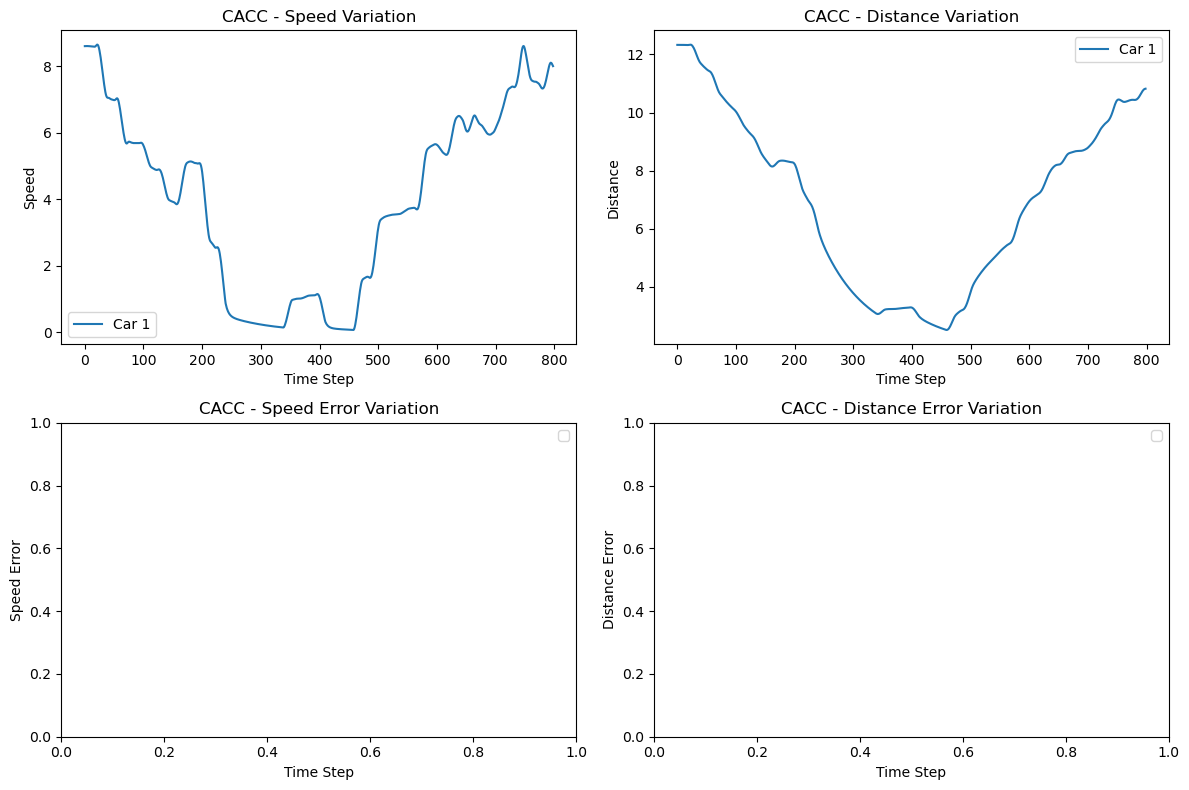

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Error plotting speed error for Car 1: list index out of range
Error plotting distance error for Car 1: list index out of range


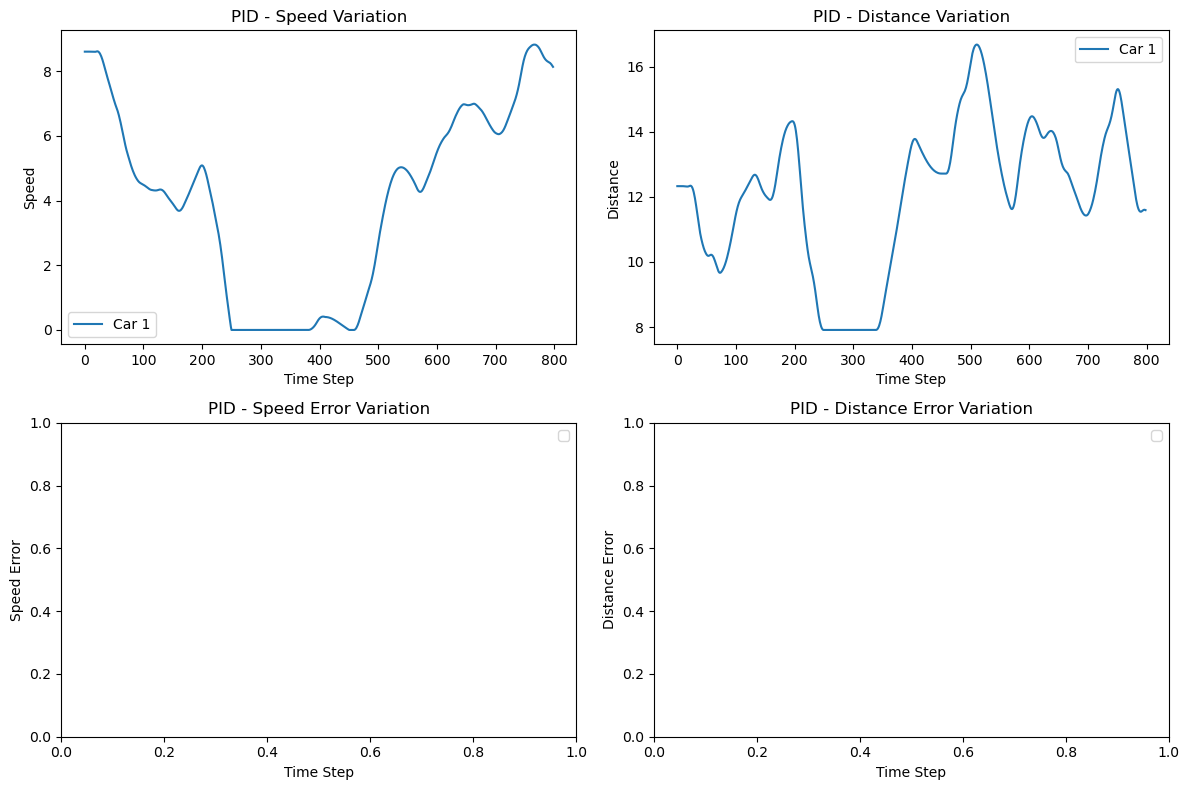

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Error plotting speed error for Car 1: list index out of range
Error plotting distance error for Car 1: list index out of range


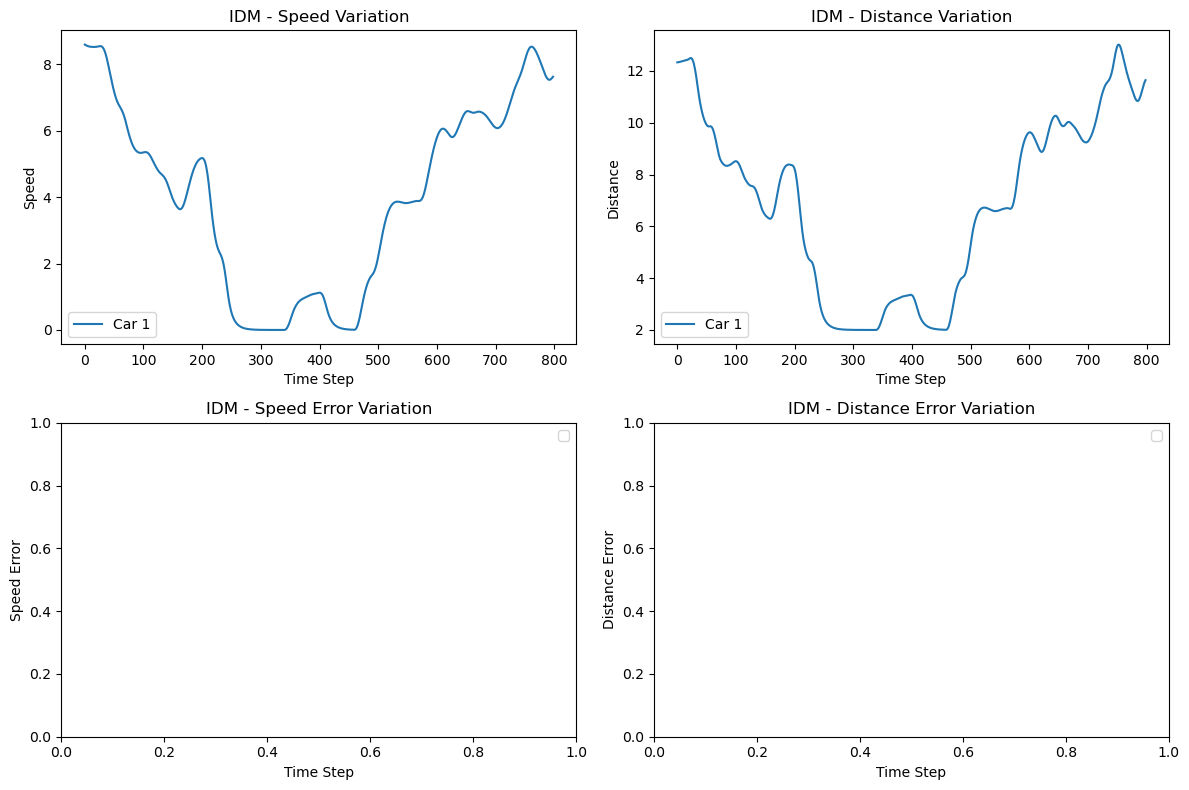

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Error plotting speed error for Car 1: list index out of range
Error plotting distance error for Car 1: list index out of range


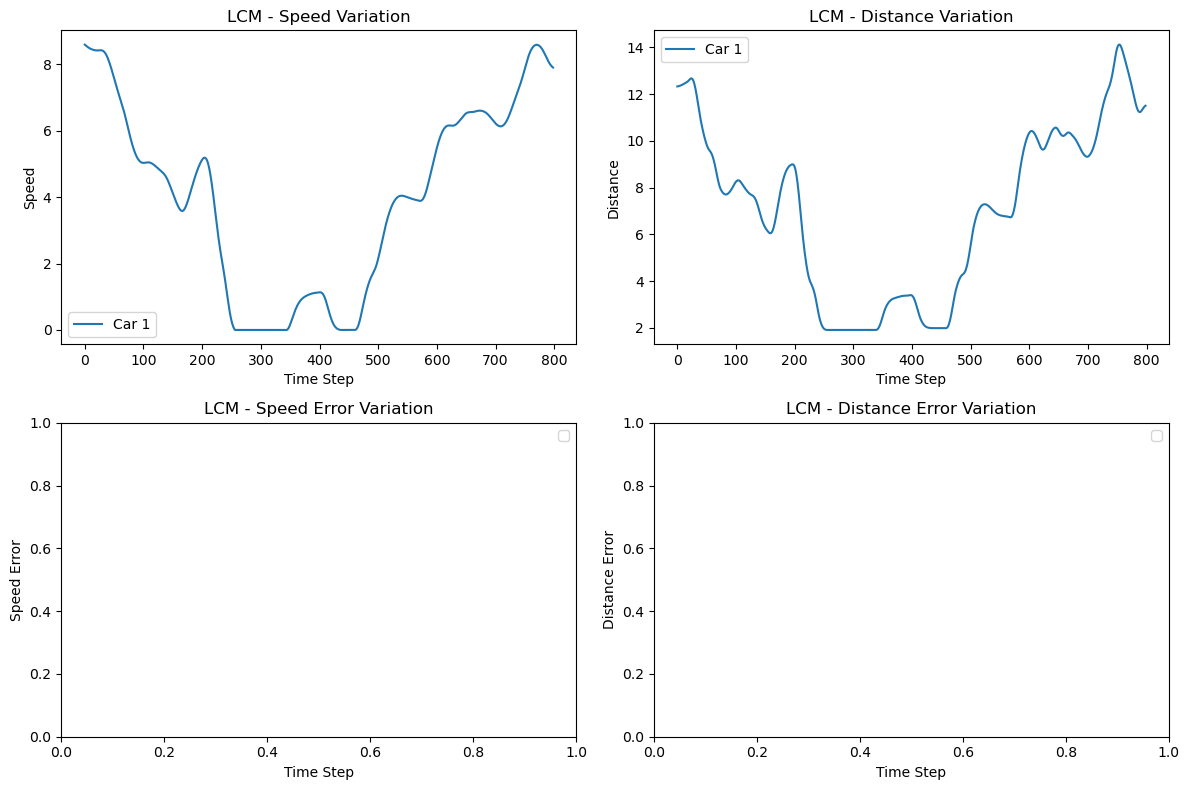

In [20]:


def plot_following_behavior(carlist, result_trajectory, controller, traj_idx):
    # 检查 carlist 是否为空
    if not carlist:
        print("Error: carlist is empty!")
        return
    
    # 检查 carlist 中的元素是否是车辆对象（假设是 Car 类）
    if not hasattr(carlist[0], 'm_id') or not hasattr(carlist[0], 'm_vellist_list'):
        print(f"Error: carlist elements are not valid Car objects! Type: {type(carlist[0])}")
        return
    
    followers = carlist[1:]  # 跟驰车辆（排除头车）
    if not followers:
        print("Warning: No followers in carlist!")
        return
    
    # 获取时间步数
    try:
        time_steps = len(result_trajectory[controller][traj_idx].m_vellist)
    except (KeyError, IndexError, AttributeError) as e:
        print(f"Error getting time_steps: {e}")
        return
    
    plt.figure(figsize=(12, 8))

    # 速度变化图
    plt.subplot(2, 2, 1)
    for car in followers:
        try:
            # 检查 car 是否有 m_vellist_list 属性
            if not hasattr(car, 'm_vellist_list'):
                print(f"Car {car.m_id} has no m_vellist_list attribute!")
                continue
            # 检查 traj_idx 是否在 m_vellist_list 范围内
            if traj_idx >= len(car.m_vellist_list):
                print(f"Traj_idx {traj_idx} out of range for Car {car.m_id} (m_vellist_list length: {len(car.m_vellist_list)})")
                continue
            plt.plot(car.m_vellist_list[traj_idx], label=f"Car {car.m_id}")
        except Exception as e:
            print(f"Error plotting speed for Car {car.m_id}: {e}")
    
    plt.title(f"{controller} - Speed Variation")
    plt.xlabel("Time Step")
    plt.ylabel("Speed")
    plt.legend()

    # 距离变化图
    plt.subplot(2, 2, 2)
    for car in followers:
        try:
            if not hasattr(car, 'm_dislist_list'):
                print(f"Car {car.m_id} has no m_dislist_list attribute!")
                continue
            if traj_idx >= len(car.m_dislist_list):
                print(f"Traj_idx {traj_idx} out of range for Car {car.m_id} (m_dislist_list length: {len(car.m_dislist_list)})")
                continue
            plt.plot(car.m_dislist_list[traj_idx], label=f"Car {car.m_id}")
        except Exception as e:
            print(f"Error plotting distance for Car {car.m_id}: {e}")
    
    plt.title(f"{controller} - Distance Variation")
    plt.xlabel("Time Step")
    plt.ylabel("Distance")
    plt.legend()

    # 速度误差变化图
    plt.subplot(2, 2, 3)
    for car in followers:
        try:
            if not hasattr(car, 'm_vellist_list') or not hasattr(carlist[car.m_id - 1], 'm_vellist_list'):
                print(f"Missing m_vellist_list attribute for Car {car.m_id} or its leader!")
                continue
            if traj_idx >= len(car.m_vellist_list) or traj_idx >= len(carlist[car.m_id - 1].m_vellist_list):
                print(f"Traj_idx {traj_idx} out of range for Car {car.m_id} or its leader!")
                continue
            vel_error = [
                abs(car.m_vellist_list[traj_idx][i] - carlist[car.m_id - 1].m_vellist_list[traj_idx][i]) 
                for i in range(time_steps)
            ]
            plt.plot(vel_error, label=f"Car {car.m_id}")
        except Exception as e:
            print(f"Error plotting speed error for Car {car.m_id}: {e}")
    
    plt.title(f"{controller} - Speed Error Variation")
    plt.xlabel("Time Step")
    plt.ylabel("Speed Error")
    plt.legend()

    # 距离误差变化图
    plt.subplot(2, 2, 4)
    for car in followers:
        try:
            if not hasattr(car, 'm_dislist_list') or not hasattr(car, 'm_h_T') or not hasattr(car, 'm_s0'):
                print(f"Missing attributes for Car {car.m_id} (m_dislist_list, m_h_T, or m_s0)!")
                continue
            if traj_idx >= len(car.m_dislist_list):
                print(f"Traj_idx {traj_idx} out of range for Car {car.m_id} (m_dislist_list length: {len(car.m_dislist_list)})")
                continue
            expect_dis = [
                car.m_h_T * car.m_vellist_list[traj_idx][i] + car.m_s0 
                for i in range(time_steps)
            ]
            dis_error = [
                abs(car.m_dislist_list[traj_idx][i] - expect_dis[i]) 
                for i in range(time_steps)
            ]
            plt.plot(dis_error, label=f"Car {car.m_id}")
        except Exception as e:
            print(f"Error plotting distance error for Car {car.m_id}: {e}")
    
    plt.title(f"{controller} - Distance Error Variation")
    plt.xlabel("Time Step")
    plt.ylabel("Distance Error")
    plt.legend()

    plt.tight_layout()
    plt.show()

# 随机选择一条轨迹
controllers = ["CACC", "PID", "IDM", "LCM"]
traj_idx = random.randint(0, len(gen_result_trajectory["LCM"]) - 1)

# 为每个控制器绘制图表
for ctrl in controllers:
    plot_following_behavior(gen_result_carlist[ctrl], gen_result_trajectory, ctrl, traj_idx)